# Credit Card Customer Segmentation — Unsupervised Learning

**Capstone Project | Boston Institute of Analytics**

**Objective:** Develop unsupervised learning models to segment credit card customers based on
spending and payment behavior, enabling improved targeted marketing, credit risk assessment,
and customer relationship management.

**Dataset:** `Customer_Data.csv` — 8,950 credit card customers, 17 behavioral/financial features
(balance, purchases, cash advances, payments, credit limit, tenure, etc.)

**Approach:**
1. Data Exploration (EDA)
2. Data Preprocessing (missing values, outliers, scaling, feature engineering)
3. Dimensionality Reduction (PCA, t-SNE)
4. Model Selection (K-Means, Agglomerative Clustering)
5. Performance Evaluation (Silhouette, Calinski-Harabasz, Davies-Bouldin)
6. Cluster Profiling & Business Interpretation


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.colors import ListedColormap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Data Exploration (EDA)

Load the dataset and inspect its structure, missing values, and summary statistics.

In [2]:
df = pd.read_csv("Customer_Data.csv")
print("Shape:", df.shape)
df.head()


Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [4]:
# Missing value check
missing = df.isnull().sum()
missing[missing > 0]


CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

`CREDIT_LIMIT` has 1 missing value and `MINIMUM_PAYMENTS` has 313 missing values (~3.5% of
rows). Both will be imputed with the median, which is robust to the heavy right-skew typical of
financial variables.

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


### 2.1 Distribution of Key Features

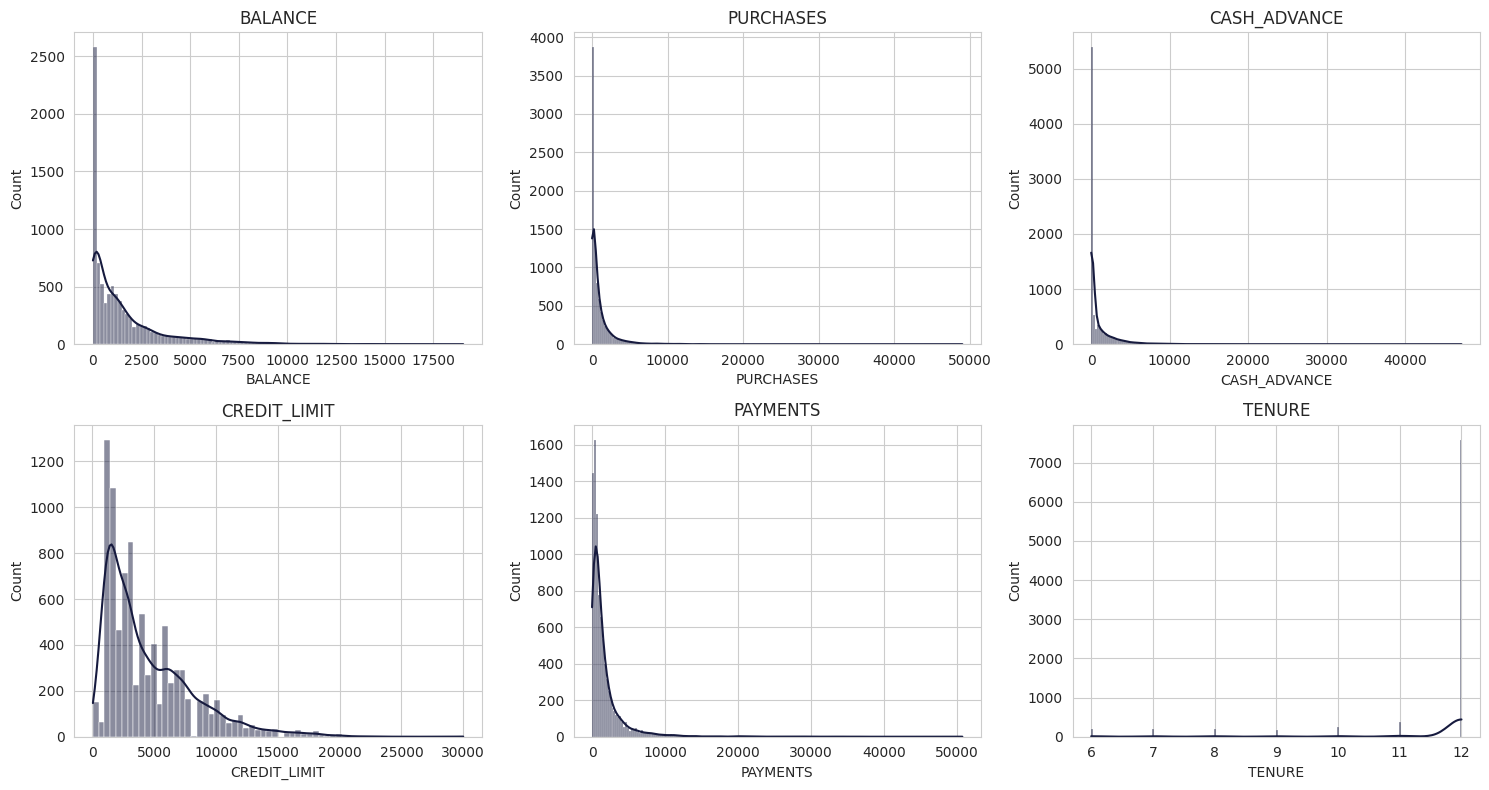

In [6]:
key_feats = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "TENURE"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, key_feats):
    sns.histplot(df[col], kde=True, ax=ax, color="#161A3E")
    ax.set_title(col)
plt.tight_layout()
plt.show()


Most monetary features (`BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`) are heavily
right-skewed with a long tail of high-value customers — this motivates a log transform before
clustering. `TENURE` is heavily concentrated at 12 months (long-standing customers dominate the
dataset).

### 2.2 Correlation Structure

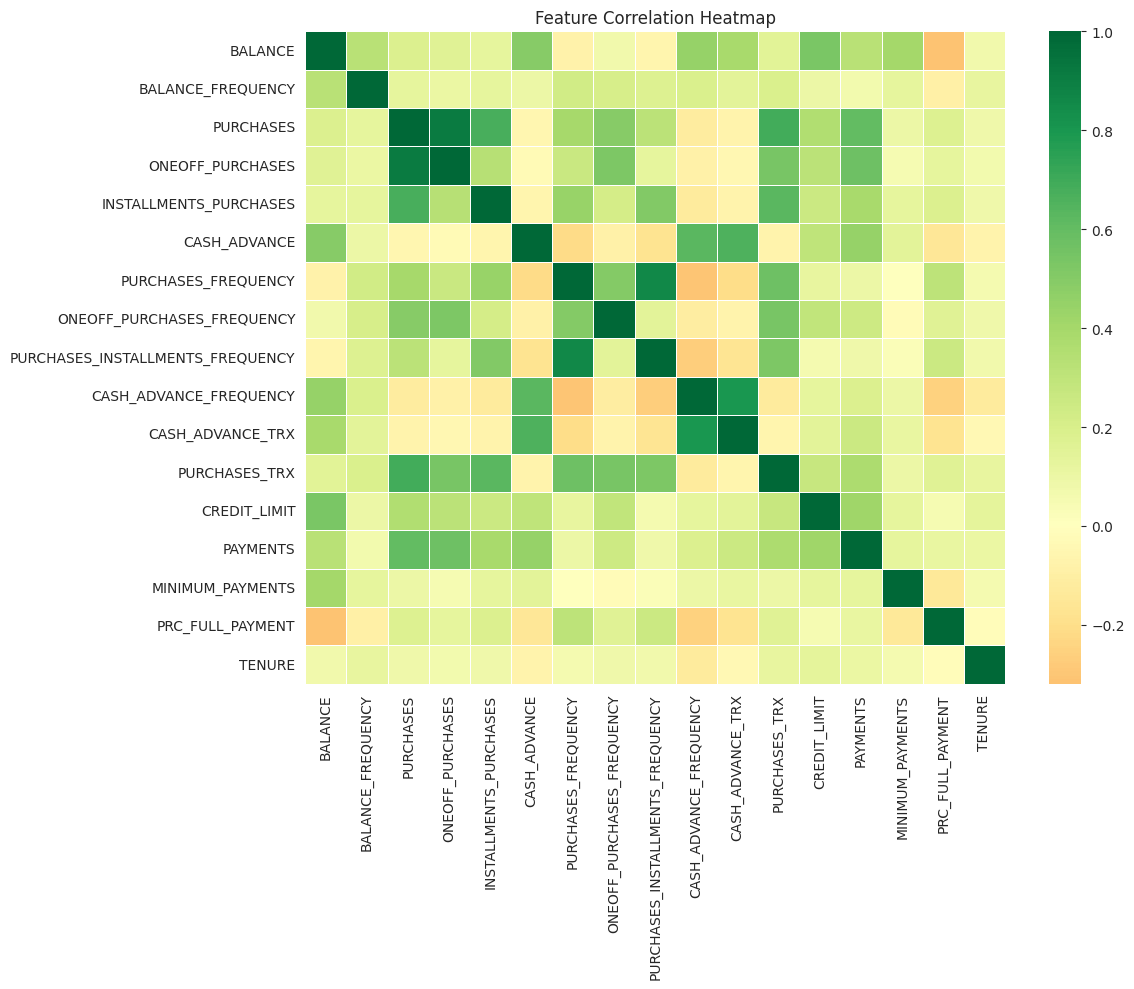

In [7]:
plt.figure(figsize=(12, 10))
corr = df.drop(columns=["CUST_ID"]).corr()
sns.heatmap(corr, cmap="RdYlGn", center=0, linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


`PURCHASES` is strongly correlated with `ONEOFF_PURCHASES` and `INSTALLMENTS_PURCHASES` (by
construction, since it's their sum), and the purchase-frequency features are mutually correlated.
This multicollinearity is a strong argument for PCA before clustering.

### 2.3 Outlier Inspection

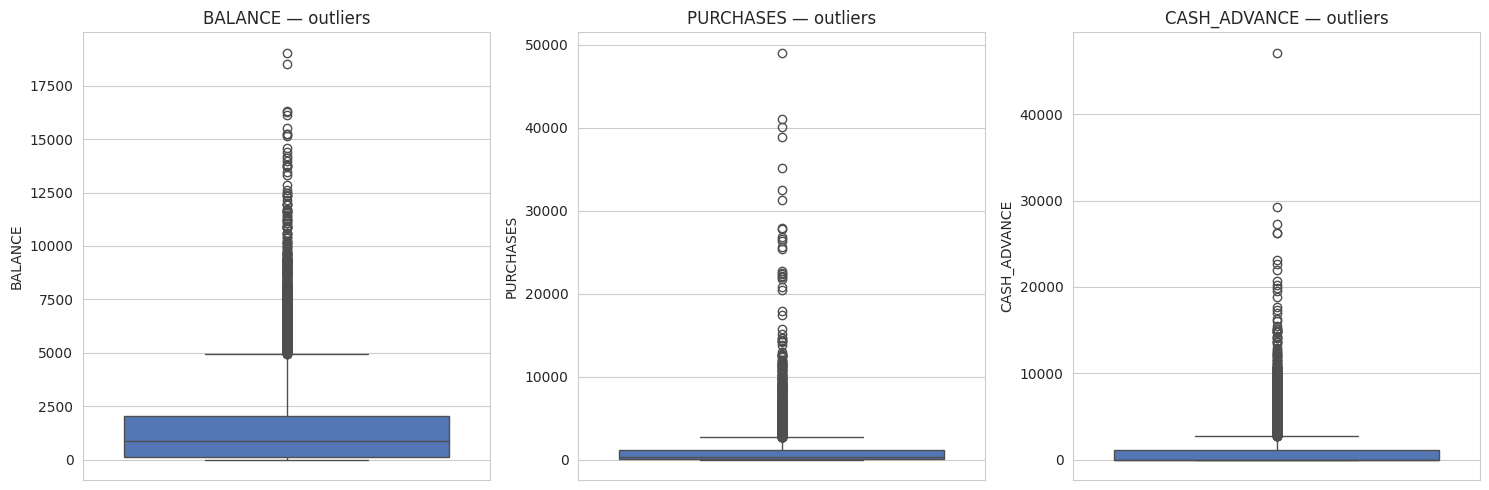

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["BALANCE", "PURCHASES", "CASH_ADVANCE"]):
    sns.boxplot(y=df[col], ax=ax, color="#4472C4")
    ax.set_title(f"{col} — outliers")
plt.tight_layout()
plt.show()


All three variables show substantial high-end outliers (a small number of customers with
very large balances / purchases / cash advances). These will be capped at the 99th percentile
during preprocessing so extreme values don't dominate distance-based clustering.

## 3. Data Preprocessing

Steps:
1. Impute missing values (median)
2. Feature engineering (behavioral ratios)
3. Cap outliers at the 99th percentile
4. Log-transform skewed monetary columns
5. Standardize (z-score) all features


In [9]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

cust_id = df["CUST_ID"]
X = df.drop(columns=["CUST_ID"])
print("Missing values remaining:", X.isnull().sum().sum())


Missing values remaining: 0


### 3.1 Feature Engineering

Derive behavioral ratios that better capture *how* customers use credit, not just raw totals.

In [10]:
eps = 1e-4
X["MONTHLY_AVG_PURCHASE"] = X["PURCHASES"] / X["TENURE"]
X["MONTHLY_CASH_ADVANCE"] = X["CASH_ADVANCE"] / X["TENURE"]
X["LIMIT_USAGE"] = X["BALANCE"] / (X["CREDIT_LIMIT"] + eps)          # credit utilization
X["PAYMENT_TO_MIN_RATIO"] = X["PAYMENTS"] / (X["MINIMUM_PAYMENTS"] + eps)  # repayment strength
X["ONEOFF_INSTALLMENT_RATIO"] = X["ONEOFF_PURCHASES"] / (X["PURCHASES"] + eps)  # purchase style

feature_cols = list(X.columns)
print(f"Total features after engineering: {len(feature_cols)} (5 new features added)")
X[["MONTHLY_AVG_PURCHASE", "LIMIT_USAGE", "PAYMENT_TO_MIN_RATIO"]].describe().T


Total features after engineering: 22 (5 new features added)


,count,mean,std,min,25%,50%,75%,max
MONTHLY_AVG_PURCHASE,8950.0,86.175173,180.508787,0.0,3.399375,31.936667,97.228333,4086.630833
LIMIT_USAGE,8950.0,0.388884,0.389721,0.0,0.041494,0.302720,0.717571,15.909919
PAYMENT_TO_MIN_RATIO,8950.0,9.053852,117.959411,0.0,0.913275,2.032716,6.052727,6837.918808


### 3.2 Outlier Capping & Log Transform

In [11]:
X_capped = X.copy()
for col in X_capped.columns:
    cap = X_capped[col].quantile(0.99)
    X_capped[col] = np.where(X_capped[col] > cap, cap, X_capped[col])

log_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
            "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX", "PAYMENTS",
            "MINIMUM_PAYMENTS", "MONTHLY_AVG_PURCHASE", "MONTHLY_CASH_ADVANCE"]
X_log = X_capped.copy()
for col in log_cols:
    X_log[col] = np.log1p(X_log[col])

print("Skew before log transform:", X_capped["BALANCE"].skew().round(2))
print("Skew after log transform: ", X_log["BALANCE"].skew().round(2))


Skew before log transform: 1.93
Skew after log transform:  -0.87


### 3.3 Standardization

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().T[["mean", "std"]].round(2).head()


,mean,std
BALANCE,-0.0,1.0
BALANCE_FREQUENCY,0.0,1.0
PURCHASES,-0.0,1.0
ONEOFF_PURCHASES,0.0,1.0
INSTALLMENTS_PURCHASES,0.0,1.0


## 4. Dimensionality Reduction

### 4.1 PCA — how many components?

We fit PCA on all standardized features and inspect the cumulative explained variance to decide
how many components are needed to retain ~90% of the information.

Components needed for 90% variance: 9 (out of 22 features)


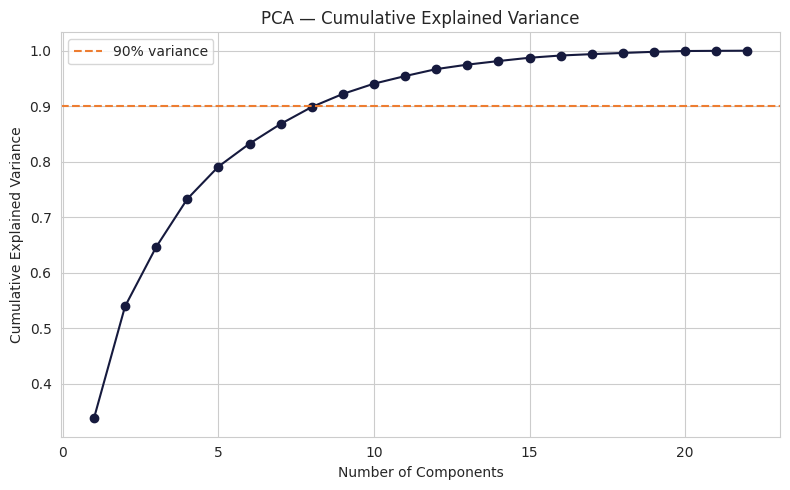

In [13]:
pca_full = PCA(n_components=len(feature_cols), random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90} (out of {len(feature_cols)} features)")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#161A3E")
plt.axhline(0.90, color="#ED7D31", linestyle="--", label="90% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 2D Projections for Visualization (PCA & t-SNE)

In [14]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"2D PCA explains {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance")

tsne = TSNE(n_components=2, random_state=42, perplexity=40, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE embedding computed.")


2D PCA explains 53.9% of variance


t-SNE embedding computed.


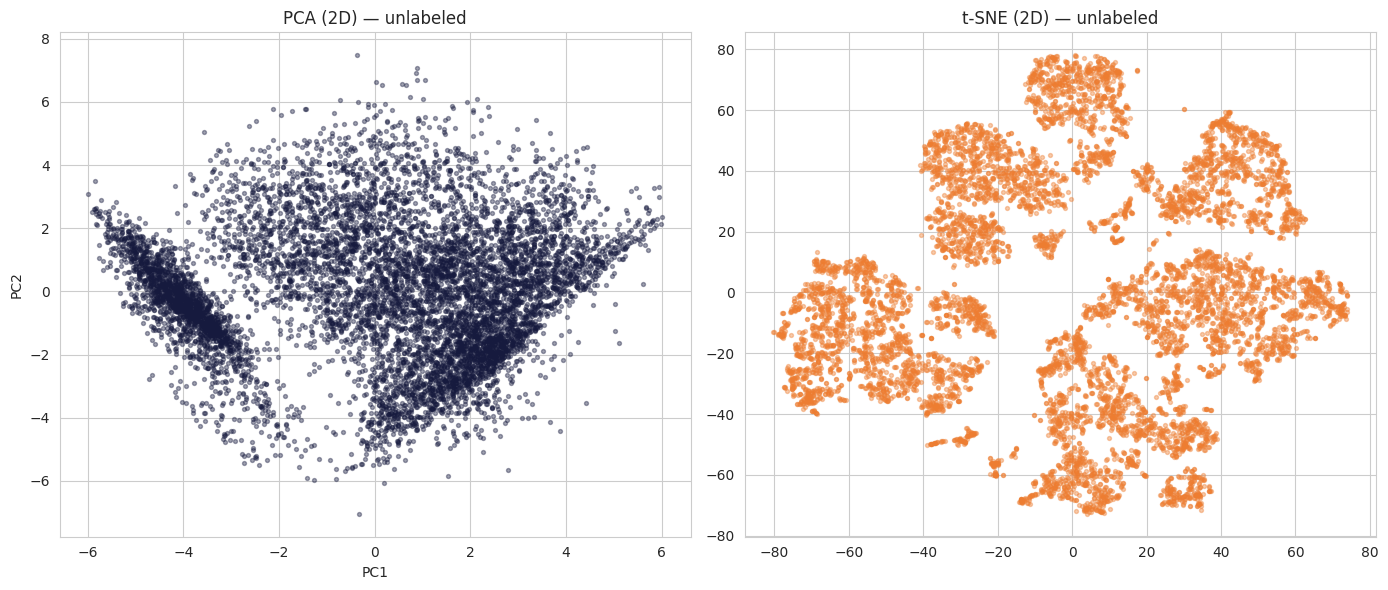

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=8, alpha=0.4, color="#161A3E")
axes[0].set_title("PCA (2D) — unlabeled")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], s=8, alpha=0.4, color="#ED7D31")
axes[1].set_title("t-SNE (2D) — unlabeled")
plt.tight_layout()
plt.show()


We use the **reduced PCA space (9 components, ~90% variance)** — not the raw 22 standardized
features — as the input to clustering below. This removes noise and multicollinearity while
retaining almost all the signal.

In [16]:
pca_reduced = PCA(n_components=n_components_90, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)
print("Clustering input shape:", X_pca_reduced.shape)


Clustering input shape: (8950, 9)


## 5. Model Selection

### 5.1 K-Means — Elbow Method + Silhouette Analysis

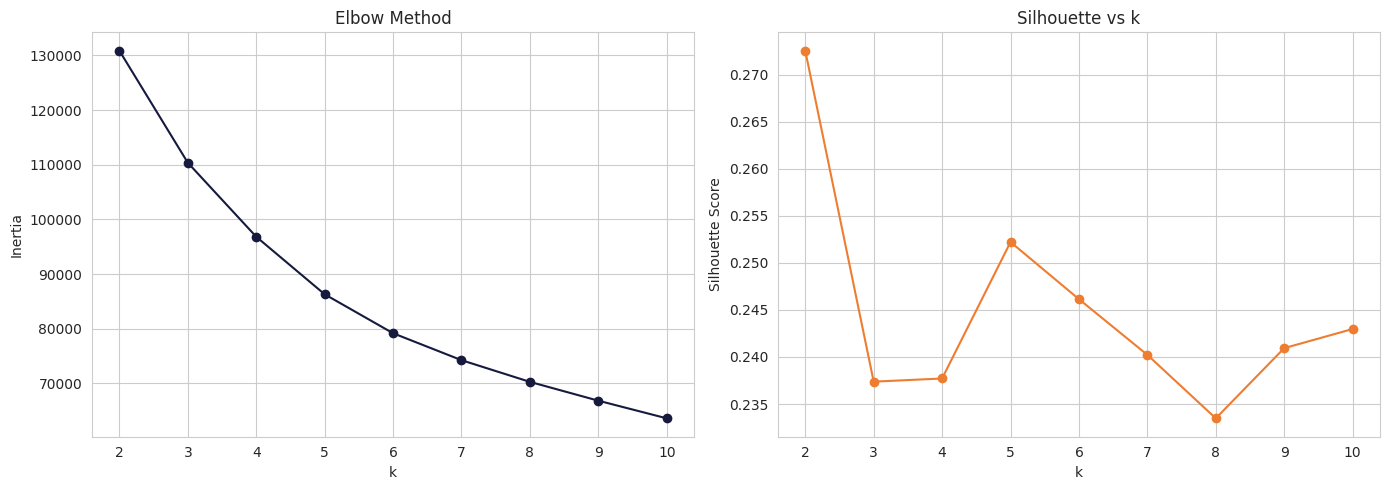

,k,inertia,silhouette
0,2,130867.045,0.273
1,3,110378.652,0.237
2,4,96841.471,0.238
3,5,86314.758,0.252
4,6,79192.511,0.246
5,7,74263.548,0.240
6,8,70294.652,0.233
7,9,66853.802,0.241
8,10,63625.676,0.243


In [17]:
k_range = range(2, 11)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_reduced)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_reduced, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#161A3E")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")
axes[1].plot(list(k_range), sil_scores, marker="o", color="#ED7D31")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette vs k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette": sil_scores}).round(3)


**Choosing k:** Silhouette score is numerically maximized at **k=2** (score ≈ 0.27), but a
2-segment split is too coarse to be actionable for differentiated marketing or risk strategies —
it essentially separates "active" from "inactive" customers and discards richer structure. The
elbow curve flattens noticeably by **k=4**, and k=4 is the strongest silhouette score among
solutions with k≥3. We therefore select **k=4** as the final, business-facing K-Means model —
a standard trade-off in applied clustering between pure statistical fit and business
interpretability.

In [18]:
best_k = 4
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca_reduced)

kmeans_metrics = {
    "Silhouette": silhouette_score(X_pca_reduced, kmeans_labels),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca_reduced, kmeans_labels),
    "Davies-Bouldin": davies_bouldin_score(X_pca_reduced, kmeans_labels),
}
pd.Series(kmeans_metrics, name="K-Means (k=4)").round(3)


Silhouette              0.238
Calinski-Harabasz    2608.853
Davies-Bouldin          1.617
Name: K-Means (k=4), dtype: float64

### 5.2 Agglomerative (Hierarchical) Clustering

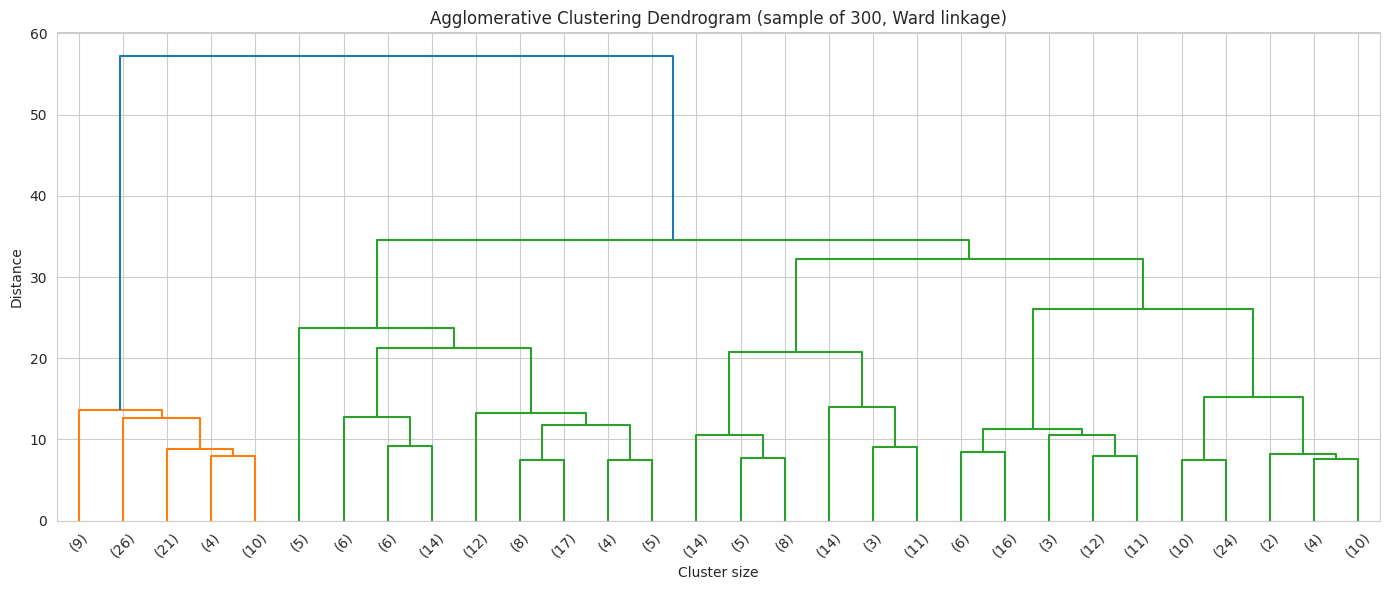

In [19]:
# Dendrogram on a random sample of 300 customers (full dataset is too large to plot legibly)
sample_idx = np.random.RandomState(42).choice(len(X_pca_reduced), size=300, replace=False)
Z = linkage(X_pca_reduced[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Agglomerative Clustering Dendrogram (sample of 300, Ward linkage)")
plt.xlabel("Cluster size"); plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [20]:
agg_sil_scores = []
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca_reduced)
    agg_sil_scores.append(silhouette_score(X_pca_reduced, labels))

pd.DataFrame({"k": list(k_range), "silhouette": agg_sil_scores}).round(3)


,k,silhouette
0,2,0.244
1,3,0.216
2,4,0.194
3,5,0.183
4,6,0.186
5,7,0.187
6,8,0.191
7,9,0.197
8,10,0.184


For a fair, apples-to-apples comparison with K-Means, we also fit Agglomerative Clustering
with **k=4**.

In [21]:
best_k_agg = 4
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
agg_labels = agg_final.fit_predict(X_pca_reduced)

agg_metrics = {
    "Silhouette": silhouette_score(X_pca_reduced, agg_labels),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca_reduced, agg_labels),
    "Davies-Bouldin": davies_bouldin_score(X_pca_reduced, agg_labels),
}
pd.Series(agg_metrics, name="Agglomerative (k=4)").round(3)


Silhouette              0.194
Calinski-Harabasz    2138.723
Davies-Bouldin          1.798
Name: Agglomerative (k=4), dtype: float64

## 6. Comparative Analysis

Side-by-side metric comparison and visual comparison of both algorithms in PCA and t-SNE space.

In [22]:
comparison = pd.DataFrame({"K-Means": kmeans_metrics, "Agglomerative": agg_metrics}).round(3)
comparison


,K-Means,Agglomerative
Silhouette,0.238,0.194
Calinski-Harabasz,2608.853,2138.723
Davies-Bouldin,1.617,1.798


K-Means achieves a higher Silhouette score and Calinski-Harabasz score, and a lower
Davies-Bouldin score, than Agglomerative Clustering at k=4 — indicating **denser, better
separated clusters**. K-Means is also far more scalable (near-linear vs. Agglomerative's
quadratic memory/time complexity), which matters for a growing customer base. **K-Means is
selected as the final production model**; Agglomerative's dendrogram remains useful as a
diagnostic/validation tool.

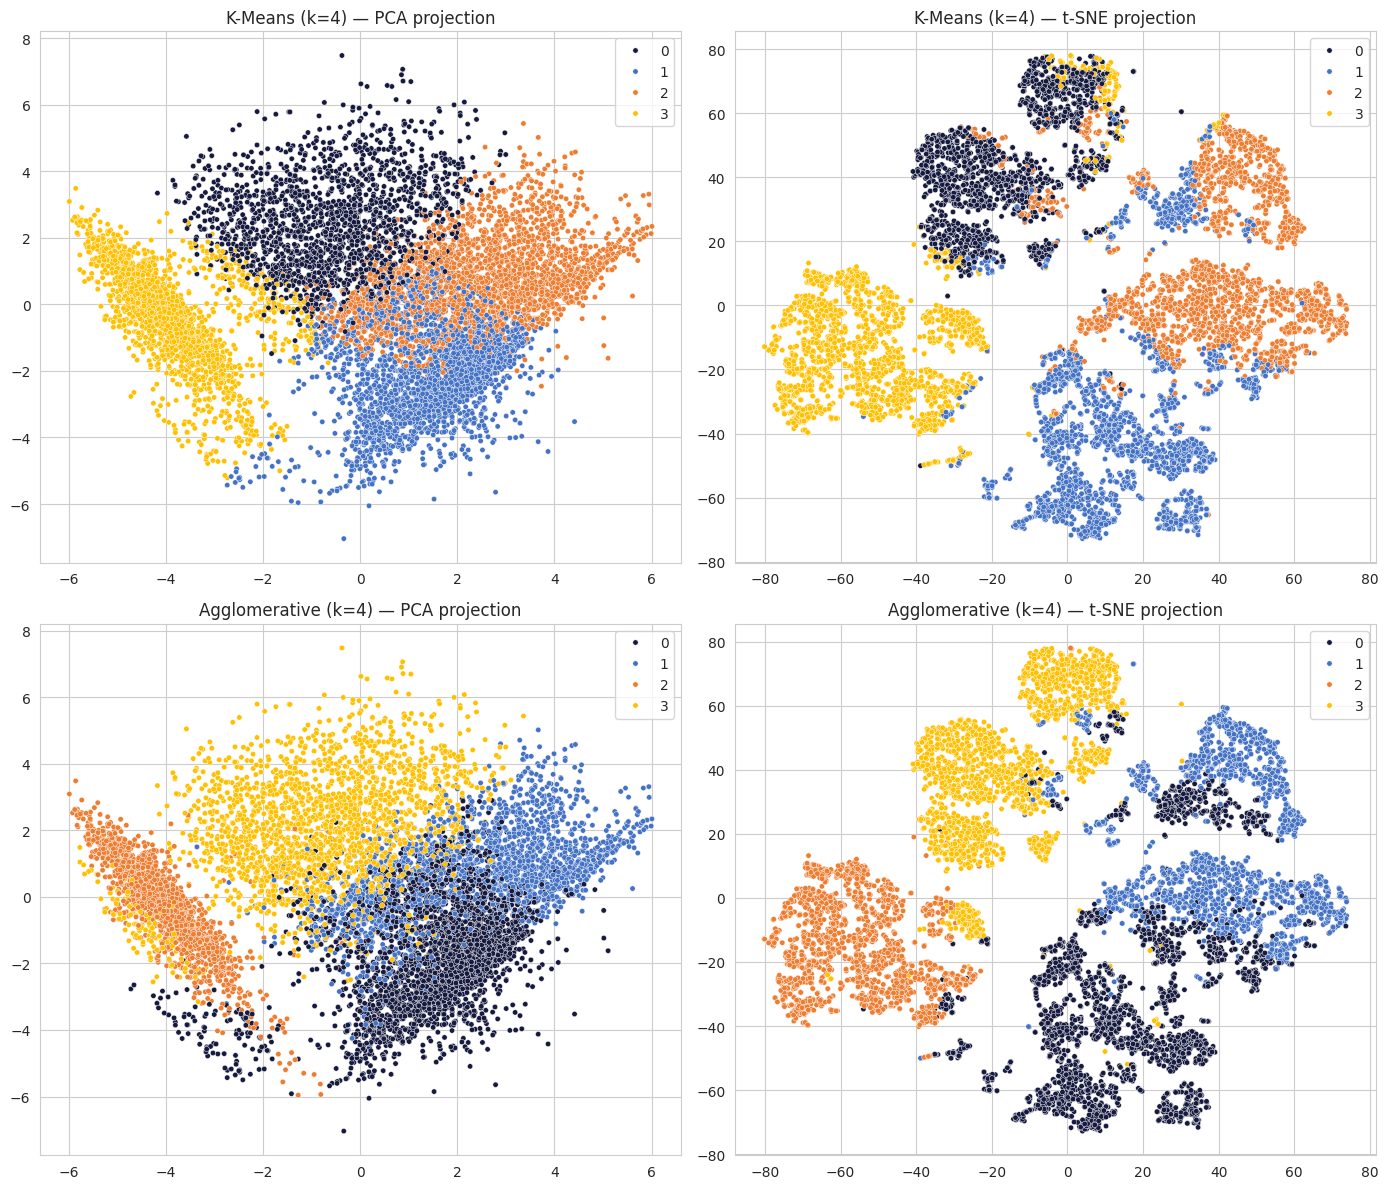

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
palette = sns.color_palette(["#161A3E", "#4472C4", "#ED7D31", "#FFC000"], best_k)

sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=kmeans_labels, palette=palette, s=15, ax=axes[0, 0])
axes[0, 0].set_title(f"K-Means (k={best_k}) — PCA projection")
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette=palette, s=15, ax=axes[0, 1])
axes[0, 1].set_title(f"K-Means (k={best_k}) — t-SNE projection")

sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=agg_labels, palette=palette, s=15, ax=axes[1, 0])
axes[1, 0].set_title(f"Agglomerative (k={best_k_agg}) — PCA projection")
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=agg_labels, palette=palette, s=15, ax=axes[1, 1])
axes[1, 1].set_title(f"Agglomerative (k={best_k_agg}) — t-SNE projection")

plt.tight_layout()
plt.show()


## 7. Cluster Profiling & Business Interpretation

Using the final K-Means (k=4) segmentation, profile each cluster on the original (unscaled)
business features to translate statistical clusters into actionable customer segments.

In [24]:
df_profile = df.copy()
df_profile["Cluster"] = kmeans_labels

profile_cols = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
                "PRC_FULL_PAYMENT", "TENURE"]
cluster_profile = df_profile.groupby("Cluster")[profile_cols].mean().round(1)
cluster_profile["Size"] = df_profile["Cluster"].value_counts().sort_index()
cluster_profile["Pct"] = (cluster_profile["Size"] / len(df_profile) * 100).round(1)
cluster_profile


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Size,Pct
Cluster,,,,,,,,,,,,
0,3064.9,1205.7,715.1,490.8,2419.7,5383.0,2552.8,1420.7,0.0,11.4,1746,19.5
1,244.0,450.6,54.6,396.5,17.9,3098.2,624.5,384.6,0.3,11.4,2492,27.8
2,1319.6,2349.0,1600.4,749.0,35.2,5783.0,2369.2,751.6,0.2,11.8,2441,27.3
3,2123.0,7.3,4.9,2.5,1939.9,3957.8,1635.8,1007.6,0.0,11.4,2271,25.4


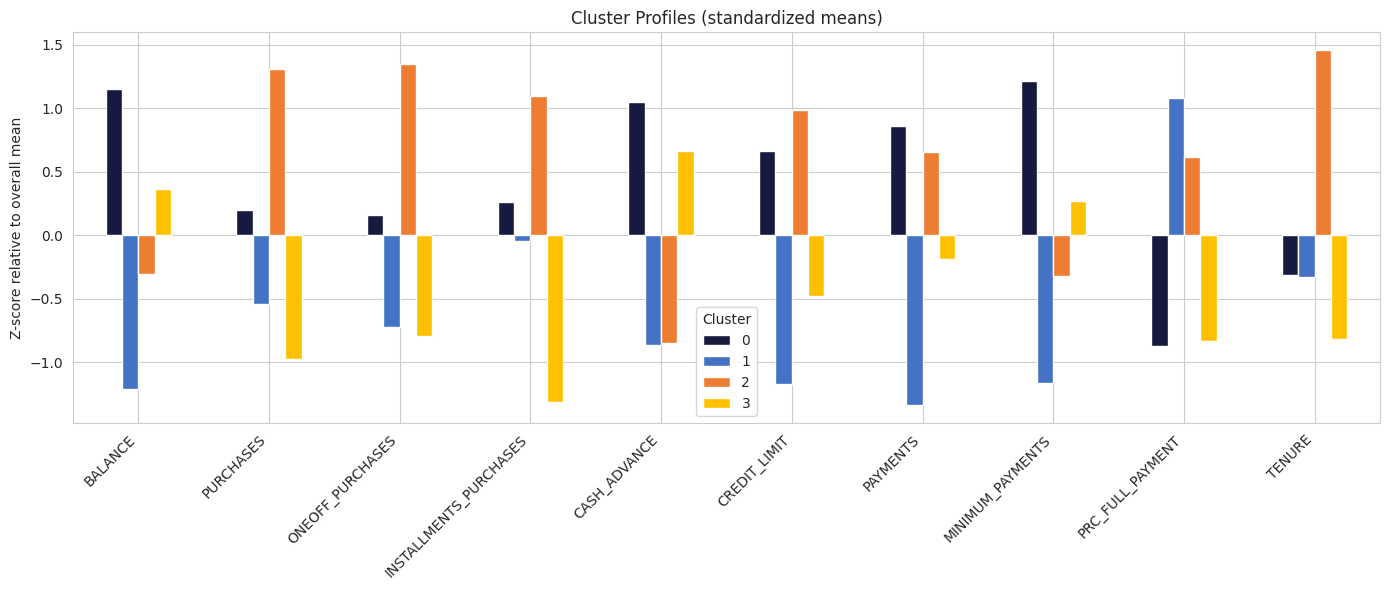

In [25]:
scaled_profile = df_profile.groupby("Cluster")[profile_cols].mean()
scaled_profile_z = (scaled_profile - scaled_profile.mean()) / scaled_profile.std()

plt.figure(figsize=(14, 6))
scaled_profile_z.T.plot(kind="bar", ax=plt.gca(), colormap=ListedColormap(["#161A3E", "#4472C4", "#ED7D31", "#FFC000"]))
plt.title("Cluster Profiles (standardized means)")
plt.ylabel("Z-score relative to overall mean")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### Segment Interpretation

| Cluster | Name | Profile | Recommended Action |
|---|---|---|---|
| **0** (19.5%) | **Revolving Big Spenders** | High balance, high cash advance, moderate purchases, ~0% pay in full | Highest credit-risk segment; prioritize for risk monitoring, offer balance-transfer or structured repayment plans |
| **1** (27.8%) | **Cautious Low-Engagement** | Low balance, low purchases, low cash advance, highest full-payment rate | Under-utilizing their card; target with purchase incentives, cashback offers to raise engagement |
| **2** (27.3%) | **Active Transactors** | Highest purchases (one-off & installment), high credit limit, low cash advance | Most profitable/loyal segment; retain with premium rewards, loyalty perks, limit increases |
| **3** (25.4%) | **Cash-Advance Reliant** | High balance, near-zero purchases, high cash advance, ~0% pay in full | Card used almost exclusively for cash withdrawals; elevated risk — flag for credit review, financial-wellness outreach |

These four segments are well balanced in size (19–28% each) and behaviorally distinct, giving
marketing and risk teams clear, differentiated levers for each group.

## 8. Conclusion & Deliverables

- **Preprocessing:** Median imputation, 5 engineered behavioral ratios, 99th-percentile outlier
  capping, log-transform of skewed monetary features, standardization.
- **Dimensionality reduction:** PCA (9 components retain ~90% variance) for clustering input;
  PCA and t-SNE 2D projections for visualization.
- **Models compared:** K-Means vs. Agglomerative (Ward linkage), both at k=4 for a fair
  comparison.
- **Winner:** **K-Means (k=4)** — better Silhouette, Calinski-Harabasz, and Davies-Bouldin
  scores, and far more scalable for production use.
- **Output:** Four actionable customer segments (Revolving Big Spenders, Cautious
  Low-Engagement, Active Transactors, Cash-Advance Reliant) directly usable for targeted
  marketing, credit risk management, and retention strategy.

Segmented customer data and 2D projection coordinates are exported for use in the accompanying
interactive dashboard.

In [26]:
df_profile.to_csv("segmented_customers.csv", index=False)

coords_df = pd.DataFrame({
    "CUST_ID": cust_id,
    "PCA1": X_pca_2d[:, 0], "PCA2": X_pca_2d[:, 1],
    "TSNE1": X_tsne[:, 0], "TSNE2": X_tsne[:, 1],
    "KMeans_Cluster": kmeans_labels,
    "Agg_Cluster": agg_labels,
})
coords_df.to_csv("cluster_coords.csv", index=False)
print("Exports saved: segmented_customers.csv, cluster_coords.csv")


Exports saved: segmented_customers.csv, cluster_coords.csv
